# MLflow Tracking

04_MLflow_Tracking.ipynb
│
├── 1. Imports
├── 2. MLflow Server Setup
├── 3. Forecasting Experiment (Prophet)
├── 4. Churn Experiment (XGBoost)
├── 5. Logging Metrics & Artifacts
├── 6. Registering Models
├── 7. Staging → Production Promotion
├── 8. Champion/Challenger Validation
├── 9. Model Comparison Dashboard
└── 10. Final Summary

In [ ]:
from pathlib import Path

# Project root
ROOT_DIR = Path.cwd().parent

# Output folders
FIGURES_DIR = ROOT_DIR / "output" / "figures"
PREDICTIONS_DIR = ROOT_DIR / "output" / "predictions"
MODELS_DIR = ROOT_DIR / "output" / "models"

# Create folders automatically
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(ROOT_DIR)

In [ ]:
# Imports


import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.prophet

from mlflow.tracking import MlflowClient

# Forecasting
from prophet import Prophet

# ML Models
from xgboost import XGBClassifier

# Train/Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Metrics
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_absolute_error,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries Loaded Successfully")

✅ Libraries Loaded Successfully


## MLFlow Server Setup

In [2]:
# MLflow Configuration


MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"

mlflow.set_tracking_uri("file:./mlruns")

EXPERIMENT_NAME = "NeuralRetail_Production"

mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ MLflow Tracking URI: {MLFLOW_TRACKING_URI}")
print(f"✅ Experiment: {EXPERIMENT_NAME}")

✅ MLflow Tracking URI: http://127.0.0.1:5000
✅ Experiment: NeuralRetail_Production


In [3]:
# Verify MLflow Connection

client = MlflowClient()

experiments = client.search_experiments()

print("Available Experiments:")

for exp in experiments:
    print(exp.name)

Available Experiments:
NeuralRetail_Production


## Forecasting Experiment (Prophet)

In [4]:
#  Forecast Dataset

forecast_df = pd.read_csv('../data/processed/forecasting_features.csv')

# Rename for Prophet
forecast_df = forecast_df.rename(columns={
    "invoicedate": "ds",
    "totalprice": "y"
})

# Convert date column
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])

# Aggregate daily sales
forecast_df = (
    forecast_df
    .groupby('ds')['y']
    .sum()
    .reset_index()
)

# Sort by date
forecast_df = forecast_df.sort_values('ds')

# Train/Test Split (last 30 days)
train_df = forecast_df.iloc[:-30]
test_df = forecast_df.iloc[-30:]

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

forecast_df.head()

Train Shape: (545, 2)
Test Shape: (30, 2)


,ds,y
0,2010-01-13,5405.11
1,2010-01-14,16405.12
2,2010-01-15,8567.67
3,2010-01-17,10808.25
4,2010-01-18,8249.52


In [5]:
# Prophet Forecast Experiment


with mlflow.start_run(run_name="Prophet_Baseline") as run:

    prophet_model = Prophet(
        changepoint_prior_scale=0.05,
        seasonality_mode='multiplicative'
    )

    prophet_model.fit(train_df)

    future = prophet_model.make_future_dataframe(periods=30)
    forecast = prophet_model.predict(future)

    preds = forecast.tail(len(test_df))['yhat']

    # Metrics
    mape = mean_absolute_percentage_error(
        test_df['y'],
        preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_df['y'],
            preds
        )
    )

    # Log Parameters
    mlflow.log_param("model_type", "Prophet")
    mlflow.log_param("changepoint_prior_scale", 0.05)
    mlflow.log_param("seasonality_mode", "multiplicative")

    # Log Metrics
    mlflow.log_metric("MAPE", mape)
    mlflow.log_metric("RMSE", rmse)

    # Log Model
    mlflow.prophet.log_model(
        prophet_model,
        artifact_path="prophet_model"
    )

    # Save Run ID
    prophet_run_id = run.info.run_id

    print("✅ Prophet experiment logged")
    print("Run ID:", prophet_run_id)

16:19:25 - cmdstanpy - INFO - Chain [1] start processing
16:19:25 - cmdstanpy - INFO - Chain [1] done processing
2026/05/24 16:19:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Prophet experiment logged
Run ID: 2b5533ff3510480e990f17bb39f9ce08


## Churn Experiment (XGBoost)

In [6]:
# Churn Dataset

churn_df = pd.read_csv("../data/processed/churn_dataset.csv")

# Encode categorical column
le = LabelEncoder() 
churn_df['Segment'] = le.fit_transform(churn_df['Segment'].astype(str))


X = churn_df.drop("Churn", axis=1)
y = churn_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4542, 8)
(1136, 8)


2026/05/24 16:19:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ XGBoost Model Logged


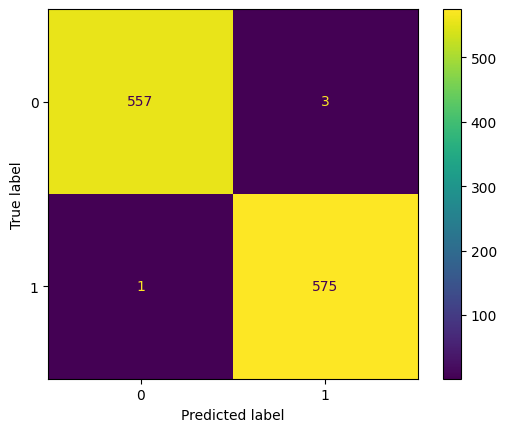

In [ ]:
# XGBoost Churn Experiment

with mlflow.start_run(run_name="XGBoost_Churn") as run:

    xgb_model = XGBClassifier(
        max_depth=6,
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    preds = xgb_model.predict(X_test)

    probs = xgb_model.predict_proba(X_test)[:,1]

    # Metrics
    auc = roc_auc_score(y_test, probs)

    f1 = f1_score(y_test, preds)

    precision = precision_score(y_test, preds)

    recall = recall_score(y_test, preds)

    # Log Params
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("n_estimators", 300)

    # Log Metrics
    mlflow.log_metric("AUC", auc)
    mlflow.log_metric("F1", f1)
    mlflow.log_metric("Precision", precision)
    mlflow.log_metric("Recall", recall)

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)

    disp = ConfusionMatrixDisplay(cm)

    disp.plot()

    plt.savefig(FIGURES_DIR / "xgb_confusion_matrix.png")

    mlflow.log_artifact("xgb_confusion_matrix.png")

    # Predictions
    prediction_df = pd.DataFrame({
        "Actual": y_test,
        "Predicted": preds,
        "Probability": probs
    })

    prediction_df.to_csv(
       PREDICTIONS_DIR / "xgb_predictions.csv",
        index=False
    )

    mlflow.log_artifact("xgb_predictions.csv")

    # Log Model
    mlflow.xgboost.log_model(
        xgb_model,
        artifact_path="xgb_model"
    )

    xgb_run_id = run.info.run_id

    print("✅ XGBoost Model Logged")

## Logging Metrics & Artifacts

In [8]:
#  Metadata Logging

metadata = {

    "project": "NeuralRetail",

    "environment": "Production",

    "random_seed": 42,

    "author": "Your Name",

    "tracking_uri": MLFLOW_TRACKING_URI
}

with open("metadata.json", "w") as f:

    json.dump(metadata, f, indent=4)

mlflow.log_artifact("metadata.json")

print("✅ Metadata Logged")

✅ Metadata Logged


## Registering Models

In [9]:
# Register Prophet Model


prophet_model_uri = f"runs:/{prophet_run_id}/prophet_model"

registered_prophet = mlflow.register_model(
    model_uri=prophet_model_uri,
    name="NeuralRetail_Prophet_Model"
)

print("✅ Prophet Model Registered")

Registered model 'NeuralRetail_Prophet_Model' already exists. Creating a new version of this model...
2026/05/24 16:19:36 WARNING mlflow.tracking._model_registry.fluent: Run with id 2b5533ff3510480e990f17bb39f9ce08 has no artifacts at artifact path 'prophet_model', registering model based on models:/m-1574337537a84614b96bf28def87da76 instead


✅ Prophet Model Registered


Created version '2' of model 'NeuralRetail_Prophet_Model'.


In [10]:
# Register XGBoost Model


xgb_model_uri = f"runs:/{xgb_run_id}/xgb_model"

registered_xgb = mlflow.register_model(
    model_uri=xgb_model_uri,
    name="NeuralRetail_XGBoost_Churn"
)

print("✅ XGBoost Registered")

Registered model 'NeuralRetail_XGBoost_Churn' already exists. Creating a new version of this model...
2026/05/24 16:19:36 WARNING mlflow.tracking._model_registry.fluent: Run with id 07d60d167825421dbca41c3750994ee8 has no artifacts at artifact path 'xgb_model', registering model based on models:/m-e59ba977692c44528a3de63ca34c7c90 instead


✅ XGBoost Registered


Created version '2' of model 'NeuralRetail_XGBoost_Churn'.


## Staging → Production Promotion

In [11]:
# Prophet → Staging


client.transition_model_version_stage(
    name="NeuralRetail_Prophet_Model",
    version=registered_prophet.version,
    stage="Staging"
)

print("✅ Prophet moved to Staging")

✅ Prophet moved to Staging


In [12]:
#  XGBoost → Staging

client.transition_model_version_stage(
    name="NeuralRetail_XGBoost_Churn",
    version=registered_xgb.version,
    stage="Staging"
)

print("✅ XGBoost moved to Staging")

✅ XGBoost moved to Staging


## Champion / Challenger Validation

In [13]:
# Champion vs Challenger


champion_auc = 0.88
challenger_auc = auc

improvement = (
    (challenger_auc - champion_auc)
    / champion_auc
) * 100

print(f"Improvement: {improvement:.2f}%")

if improvement >= 5:

    print("✅ Challenger Wins")

    client.transition_model_version_stage(
        name="NeuralRetail_XGBoost_Churn",
        version=registered_xgb.version,
        stage="Production"
    )

else:

    print("❌ Champion Retained")

Improvement: 13.63%
✅ Challenger Wins


##  Model Comparison Dashboard

In [14]:
# Model Comparison


comparison_df = pd.DataFrame({

    "Model": [
        "Prophet",
        "XGBoost"
    ],

    "Primary Metric": [
        "MAPE",
        "AUC"
    ],

    "Score": [
        round(mape, 4),
        round(auc, 4)
    ]
})

print(comparison_df)

     Model Primary Metric   Score
0  Prophet           MAPE  0.7223
1  XGBoost            AUC  1.0000
